<a href="https://colab.research.google.com/github/AlexProts/SIMILIS-artifact-classification/blob/main/SIMILIS_data_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Сетап окружения

In [2]:
import sys
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torchvision
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from tqdm.auto import tqdm
import re
from collections import Counter
from pathlib import Path

In [3]:
SEED = 98

def seed_everything(seed: int = 42) -> None:
    """Fix all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

In [4]:
DIRS = [
    "data/raw",
    "data/interim",
    "data/processed",
    "splits",
    "artifacts/checkpoints",
    "artifacts/preds",
    "artifacts/reports",
    "artifacts/figures",
]
for d in DIRS:
    os.makedirs(d, exist_ok=True)


data/raw/
data/interim/
data/processed/
splits/
artifacts/checkpoints/
artifacts/preds/
artifacts/reports/
artifacts/figures/


### Зафиксированные версии

In [ ]:
import pkg_resources, sys

REQUIRED = [
    "torch", "torchvision", "timm", "numpy", "pandas",
    "Pillow", "scikit-learn", "matplotlib", "tqdm",
    "pymorphy3", "wandb",
]

print(f"Python: {sys.version.split()[0]}")
for pkg in REQUIRED:
    try:
        v = pkg_resources.get_distribution(pkg).version
        print(f"  {pkg:<20s} {v}")
    except Exception:
        print(f"  {pkg:<20s} not installed")


# Загрузка данных

In [5]:
CSV_OLD_PATH = "/content/drive/MyDrive/pack_cu/selected_by_name_iimk_subset.csv"        # sep=';'
CSV_NEW_PATH = "/content/drive/MyDrive/cu_data/selected_by_name_iimk_subset_public.csv"  # sep=','

IMAGE_DIRS = [
    "/content/drive/MyDrive/cu_data/dataset",           # primary (preferred for dupes)
    "/content/drive/MyDrive/pack_cu/images_proc",       # secondary
]

In [6]:
def normalize_code(code: str) -> str:
    """Normalize artifact code for CSV<->filename matching.

    - Strips multi-view suffix (_1, -2) at the end
    - Strips leading zeros from last numeric segment

    'КБ-2014-Р5-0077'      -> 'КБ-2014-Р5-77'
    'ВО-1л58-2017-0983-2'  -> 'ВО-1л58-2017-983'
    """
    code = str(code).strip()
    code = re.sub(r"[_\-]\d$", "", code)
    parts = code.rsplit("-", 1)
    if len(parts) == 2 and parts[1].isdigit():
        return f"{parts[0]}-{int(parts[1])}"
    return code

In [7]:
df_old = pd.read_csv(CSV_OLD_PATH, sep=";")
df_new = pd.read_csv(CSV_NEW_PATH, sep=",")

print(f"old CSV: {df_old.shape},  columns: {list(df_old.columns)}")
print(f"new CSV: {df_new.shape},  columns: {list(df_new.columns)}")

def is_broken(code) -> bool:
    return bool(re.match(r"^\d+$", str(code)))

n_broken_old = df_old["code"].apply(is_broken).sum()
n_broken_new = df_new["code"].apply(is_broken).sum()
print(f"\nbroken rows (numeric-only code)  old: {n_broken_old}  new: {n_broken_new}")

df_old = df_old[~df_old["code"].apply(is_broken)].copy()
df_new = df_new[~df_new["code"].apply(is_broken)].copy()


Old CSV: (2973, 10), columns: ['Unnamed: 0', 'code', 'name', 'description', 'material', 'size', 'qty', 'condition', 'fragm', 'memo']
New CSV: (1389, 10), columns: ['Unnamed: 0', 'code', 'name', 'description', 'material', 'size', 'fragm', 'cultlayer', 'execorg', 'survyear']

Broken rows (numeric-only code) — old: 0, new: 2


In [8]:
df_new.head()

,Unnamed: 0,code,name,description,material,size,fragm,cultlayer,execorg,survyear
0,40,М102-2012-1-0494,Изразец,Изразца красноглиняного с белой поливой и коба...,Керамика,"7+ х 3,5+ х 1,1+ см",Фрагмент,Пестрая мешаная супесь,ИИМК РАН,2012.0
1,41,М102-2012-1-0496,Изразец,Изразца красноглиняного плоского с белой полив...,Керамика,"9,9+ х 6,4+ х 1,3+ см",Фрагмент,Пестрая мешаная супесь,ИИМК РАН,2012.0
2,49,М102-2012-1-0529,Изразец,Изразца-перемычки красноглиняного с белой поли...,Керамика,"4,5+ х 4,3 х 4,2+ см",Фрагмент,Пестрая мешаная супесь,ИИМК РАН,2012.0
3,59,М102-2012-1-0585,Тарелка,Сосуда (тарелки ?) фаянсового с белой поливой ...,Фаянс,D? см,Фрагмент,Дерн со щепой,ИИМК РАН,2012.0
4,63,М102-2012-1-0603,Изразец,Изразца (перемычки?) красноглиняного с белой п...,Керамика,"3,8+ х 2,8 х 5,1+ см",Фрагмент,Дерн со щепой,ИИМК РАН,2012.0


In [9]:
critical = ["name", "material", "fragm", "description"]
n_null_old = df_old[critical].isnull().any(axis=1).sum()
n_null_new = df_new[critical].isnull().any(axis=1).sum()
print(f"rows with null critical fields  old: {n_null_old}  new: {n_null_new}")
df_old = df_old.dropna(subset=critical).copy()
df_new = df_new.dropna(subset=critical).copy()


Rows with null critical fields — old: 0, new: 0


In [10]:
df_old["code_norm"] = df_old["code"].apply(normalize_code)
df_new["code_norm"] = df_new["code"].apply(normalize_code)


In [11]:
dup_old = df_old["code_norm"].duplicated().sum()
dup_new = df_new["code_norm"].duplicated().sum()
if dup_old or dup_new:
    print(f"within-CSV duplicates by code_norm  old: {dup_old}  new: {dup_new}")
df_old = df_old.drop_duplicates(subset="code_norm", keep="first")
df_new = df_new.drop_duplicates(subset="code_norm", keep="first")


In [12]:
# public CSV is source of truth; rows only in old CSV are appended with missing public fields
SHARED_FIELDS = ["code", "code_norm", "name", "material", "fragm", "description", "size"]
PUBLIC_EXTRA  = ["cultlayer", "execorg", "survyear"]
OLD_EXTRA     = ["memo"]

old_codes = set(df_old["code_norm"])
new_codes  = set(df_new["code_norm"])
overlap    = old_codes & new_codes
only_old   = old_codes - new_codes
only_new   = new_codes - old_codes

print(f"in both CSVs: {len(overlap)}  only old: {len(only_old)}  only new: {len(only_new)}")


=== Merge overview ===
  In both CSVs:  1387
  Only in old:   1586
  Only in new:   0


In [13]:
conflict_log      = {f: 0 for f in ["name", "material", "fragm", "description"]}
conflict_examples = {f: []  for f in conflict_log}

old_idx = df_old.set_index("code_norm")
new_idx = df_new.set_index("code_norm")

for code in overlap:
    old_row = old_idx.loc[code]
    new_row = new_idx.loc[code]
    for f in conflict_log:
        ov = str(old_row[f]).strip()
        nv = str(new_row[f]).strip()
        if ov != nv and ov != "nan" and nv != "nan":
            conflict_log[f] += 1
            if len(conflict_examples[f]) < 3:
                conflict_examples[f].append((code, ov, nv))

print("field conflicts (old vs new) in overlap — public value kept:")
for f, n in conflict_log.items():
    print(f"  {f}: {n}")
    for code, ov, nv in conflict_examples[f]:
        print(f"    {code}: old='{ov[:50]}'  new='{nv[:50]}'")



=== Field conflicts (old vs new) in overlap — public is kept ===
  name: 0 conflicts
  material: 0 conflicts
  fragm: 0 conflicts
  description: 0 conflicts


In [14]:
df_new_aug = df_new[SHARED_FIELDS + PUBLIC_EXTRA].copy()
for col in OLD_EXTRA:
    df_new_aug[col] = df_new_aug["code_norm"].map(
        df_old.set_index("code_norm")[col] if col in df_old.columns else {}
    )

df_old_only = df_old[df_old["code_norm"].isin(only_old)][SHARED_FIELDS + OLD_EXTRA].copy()
for col in PUBLIC_EXTRA:
    df_old_only[col] = None

df = pd.concat([df_new_aug, df_old_only], ignore_index=True)
df["source"] = df["code_norm"].apply(lambda c: "public" if c in new_codes else "old")

print(f"merged df: {len(df)} rows")
print(f"  from public: {(df['source'] == 'public').sum()}")
print(f"  from old only: {(df['source'] == 'old').sum()}")
print(f"  columns: {list(df.columns)}")



=== Merged DF ===
  Total rows:       2973
  From public:      1387
  From old only:    1586
  Columns:          ['code', 'code_norm', 'name', 'material', 'fragm', 'description', 'size', 'cultlayer', 'execorg', 'survyear', 'memo', 'source']


In [15]:
df.head()

,code,code_norm,name,material,fragm,description,size,cultlayer,execorg,survyear,memo,source
0,М102-2012-1-0494,М102-2012-1-494,Изразец,Керамика,Фрагмент,Изразца красноглиняного с белой поливой и коба...,"7+ х 3,5+ х 1,1+ см",Пестрая мешаная супесь,ИИМК РАН,2012.0,NaN,public
1,М102-2012-1-0496,М102-2012-1-496,Изразец,Керамика,Фрагмент,Изразца красноглиняного плоского с белой полив...,"9,9+ х 6,4+ х 1,3+ см",Пестрая мешаная супесь,ИИМК РАН,2012.0,NaN,public
2,М102-2012-1-0529,М102-2012-1-529,Изразец,Керамика,Фрагмент,Изразца-перемычки красноглиняного с белой поли...,"4,5+ х 4,3 х 4,2+ см",Пестрая мешаная супесь,ИИМК РАН,2012.0,NaN,public
3,М102-2012-1-0585,М102-2012-1-585,Тарелка,Фаянс,Фрагмент,Сосуда (тарелки ?) фаянсового с белой поливой ...,D? см,Дерн со щепой,ИИМК РАН,2012.0,NaN,public
4,М102-2012-1-0603,М102-2012-1-603,Изразец,Керамика,Фрагмент,Изразца (перемычки?) красноглиняного с белой п...,"3,8+ х 2,8 х 5,1+ см",Дерн со щепой,ИИМК РАН,2012.0,NaN,public


# Мэтч картинок и строк в датафрейме

In [16]:
def scan_folder(folder: str) -> dict[str, str]:
    """Scan folder and return {code_norm: full_path}.

    If multiple files map to the same code_norm, keeps the first one.
    """
    result = {}
    if not os.path.isdir(folder):
        print(f"Folder not found: {folder}")
        return result

    for fname in sorted(os.listdir(folder)):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        base = fname.rsplit(".", 1)[0]
        if base.endswith("_orig"):
            base = base[:-5]
        if not base:  # e.g. 'orig.jpg' alone
            continue
        norm = normalize_code(base)
        if norm not in result:
            result[norm] = os.path.join(folder, fname)
    return result

In [17]:
folder_scans = {}
for folder in IMAGE_DIRS:
    scan = scan_folder(folder)
    folder_scans[folder] = scan
    print(f"{folder}")
    print(f"  unique code_norm: {len(scan)}")

code_to_path   = {}
code_to_source = {}
for folder in IMAGE_DIRS:
    for code, path in folder_scans[folder].items():
        if code not in code_to_path:
            code_to_path[code]   = path
            code_to_source[code] = folder

if len(IMAGE_DIRS) > 1:
    dup_across = sum(
        1 for c in folder_scans[IMAGE_DIRS[0]] if c in folder_scans[IMAGE_DIRS[1]]
    )
    print(f"\ncodes in both folders (primary used): {dup_across}")


Folder /content/drive/MyDrive/cu_data/dataset
  Unique code_norm: 1388
Folder /content/drive/MyDrive/pack_cu/images_proc
  Unique code_norm: 608

Codes present in both folders (using primary): 560


In [ ]:
for folder in IMAGE_DIRS:
    if not os.path.isdir(folder):
        print(f"not found: {folder}")
        continue
    n = sum(
        1 for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    )
    print(f"{folder}")
    print(f"  image files on disk: {n}")


In [18]:
df["image_file"]   = df["code_norm"].map(code_to_path)
df["image_source"] = df["code_norm"].map(code_to_source)

n_matched = df["image_file"].notna().sum()
n_missing = df["image_file"].isna().sum()
extra     = set(code_to_path.keys()) - set(df["code_norm"])

print(f"CSV rows: {len(df)}")
print(f"  matched with image: {n_matched}")
print(f"  without image:      {n_missing}")
print(f"  image files not in CSV: {len(extra)}")
print()
print("by CSV source:")
print(df[df["image_file"].notna()]["source"].value_counts().to_string())
print()
print("by image folder:")
print(df[df["image_file"].notna()]["image_source"].value_counts().to_string())

df = df[df["image_file"].notna()].reset_index(drop=True)
print(f"\nafter filtering: {len(df)} rows")



=== Image linking ===
  CSV rows total:       2973
  Matched with image:   1186
  Without image:        1787
  Image files not in CSV: 250

=== Matched rows by CSV source ===
source
public    1139
old         47

=== Matched rows by image folder ===
image_source
/content/drive/MyDrive/cu_data/dataset        1139
/content/drive/MyDrive/pack_cu/images_proc      47
After filtering: 1186 rows with images ready for training


In [ ]:
sample_pairs = df[df["image_file"].notna()].sample(5, random_state=SEED)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (_, row) in zip(axes, sample_pairs.iterrows()):
    try:
        ax.imshow(Image.open(row["image_file"]).convert("RGB"))
    except Exception as e:
        ax.text(0.5, 0.5, str(e), ha="center", va="center",
                transform=ax.transAxes, fontsize=7)
    ax.set_title(
        f"{row['code']}\n{row['name']}\n{row['material']} / {row['fragm']}",
        fontsize=7
    )
    ax.axis("off")
plt.suptitle("5 pairs: CSV row <-> image", fontsize=12)
plt.tight_layout()
plt.savefig("artifacts/figures/row_image_pairs.png", dpi=150, bbox_inches="tight")
plt.show()

print(sample_pairs[["code", "name", "material", "fragm", "image_file"]].to_string())


In [19]:
def make_group_key(code: str) -> str:
    """'KBurr-2014-R2-0128' -> 'KBurr-2014-R2'  (excavation context, strips artifact number)."""
    parts = str(code).rsplit("-", 1)
    if len(parts) == 2 and parts[1].replace(" ", "").isdigit():
        return parts[0]
    return str(code)

df["group_key"] = df["code"].apply(make_group_key)

sizes = df.groupby("group_key").size()
print(f"unique group_keys: {df['group_key'].nunique()}")
print(f"items per group: min={sizes.min()}  max={sizes.max()}  median={sizes.median():.0f}")
print()
print("top 10 groups by size:")
print(df["group_key"].value_counts().head(10).to_string())


Unique group_keys: 72

Top-10 groups (after filtering to matched):
group_key
ВО-1л58-2017    177
Нц-45            94
КБ-2014-Р2       75
БП12-Г01         72
Нц-33            56
КБ-2014-Р5       46
Кроп-2013        39
Нц-46            37
КБ-2014-Р3       36
КБ-2014-Р1       34

Items per group: min=1, max=177, median=6


In [20]:
# silhouette masks: black background, no texture — material field unreliable
SILHOUETTE_CODES = {
    "КБ-2014-Р1-0719",
    "КБ-2014-Р2-0211",
    "КБ-2014-Р2-0218",
    "КБ-2014-Р3-0141",
    "КБ-2014-Р6-095",
    "ВО-1л58-2017-0093",
}

n_before = len(df)
df = df[~df["code"].isin(SILHOUETTE_CODES)].reset_index(drop=True)
print(f"dropped {n_before - len(df)} manually identified silhouette masks, {len(df)} rows remain")


Dropped 6 silhouette masks. Remaining: 1180


# EDA

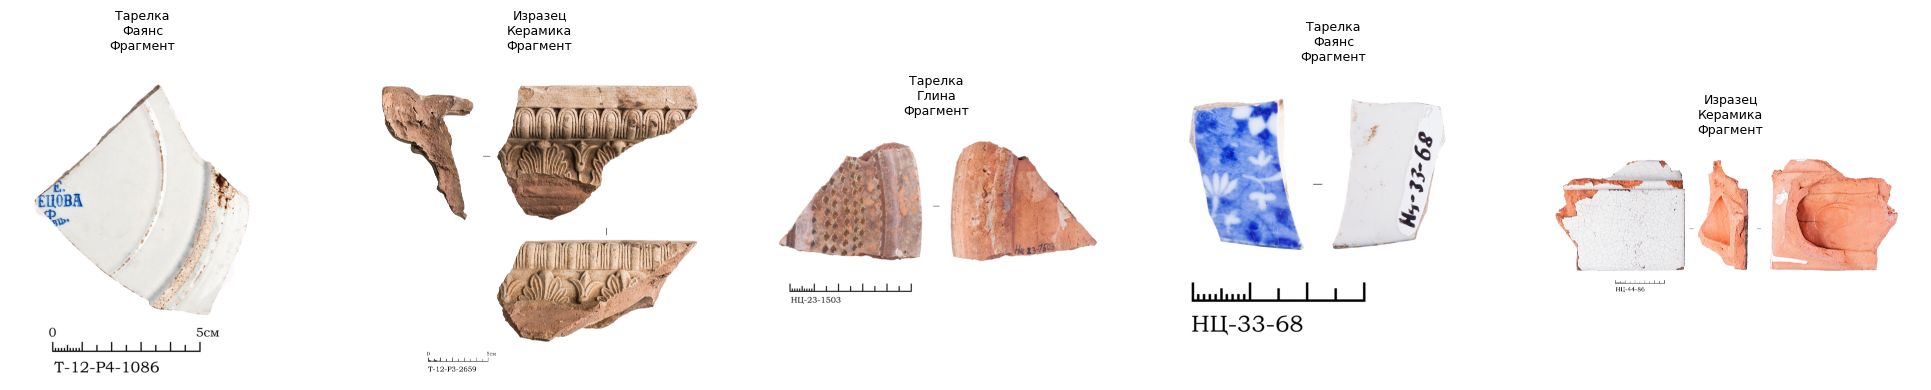

In [21]:
def show_sample_grid(df: pd.DataFrame, n: int = 12) -> None:
    """Show grid of n images with metadata captions (requires n >= 12)."""
    sample = df[df["image_file"].notna()].sample(n, random_state=SEED)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (_, row) in zip(axes, sample.iterrows()):
        try:
            img = Image.open(row["image_file"]).convert("RGB")
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {e}", ha="center", va="center",
                    transform=ax.transAxes, fontsize=7)
        ax.set_title(
            f"{row['name']}\n{row['material']} / {row['fragm']}\n{row['code']}",
            fontsize=7
        )
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.suptitle(f"Сетка из {n} изображений с метаданными", fontsize=13)
    plt.tight_layout()
    plt.savefig("artifacts/figures/sample_grid_12.png", dpi=150, bbox_inches="tight")
    plt.show()

show_sample_grid(df, n=12)


Reading image sizes:   0%|          | 0/1180 [00:00<?, ?it/s]

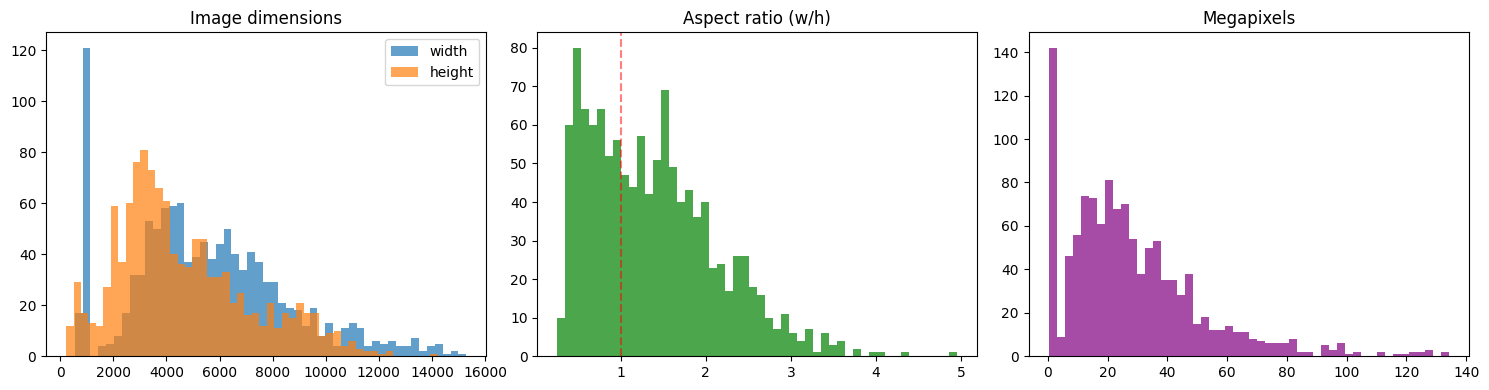

          width    height   aspect  megapixels
count   1179.00   1179.00  1179.00     1179.00
mean    5555.73   4611.84     1.39       28.29
std     3008.81   2521.38     0.75       22.83
min      543.00    218.00     0.26        0.24
25%     3531.00   2838.00     0.76       12.31
50%     5232.00   3982.00     1.28       23.47
75%     7335.00   6049.00     1.84       38.41
max    15292.00  14212.00     4.95      134.14


In [22]:
def collect_image_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Collect width, height, aspect ratio for all matched images."""
    stats = []
    for _, row in tqdm(df[df["image_file"].notna()].iterrows(),
                       total=df["image_file"].notna().sum(),
                       desc="Reading image sizes"):
        img_path =  row["image_file"]
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                stats.append({
                    "code": row["code"],
                    "width": w,
                    "height": h,
                    "aspect": w / h,
                    "megapixels": (w * h) / 1e6,
                })
        except:
            pass
    return pd.DataFrame(stats)

if df["image_file"].notna().any():
    img_stats = collect_image_stats(df)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(img_stats["width"], bins=50, alpha=0.7, label="width")
    axes[0].hist(img_stats["height"], bins=50, alpha=0.7, label="height")
    axes[0].set_title("Image dimensions")
    axes[0].legend()

    axes[1].hist(img_stats["aspect"], bins=50, color="green", alpha=0.7)
    axes[1].set_title("Aspect ratio (w/h)")
    axes[1].axvline(1.0, color="red", linestyle="--", alpha=0.5)

    axes[2].hist(img_stats["megapixels"], bins=50, color="purple", alpha=0.7)
    axes[2].set_title("Megapixels")

    plt.tight_layout()
    plt.savefig("artifacts/figures/eda_image_stats.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(img_stats[["width", "height", "aspect", "megapixels"]].describe().round(2))
else:
    print("Skipping — no matched images.")

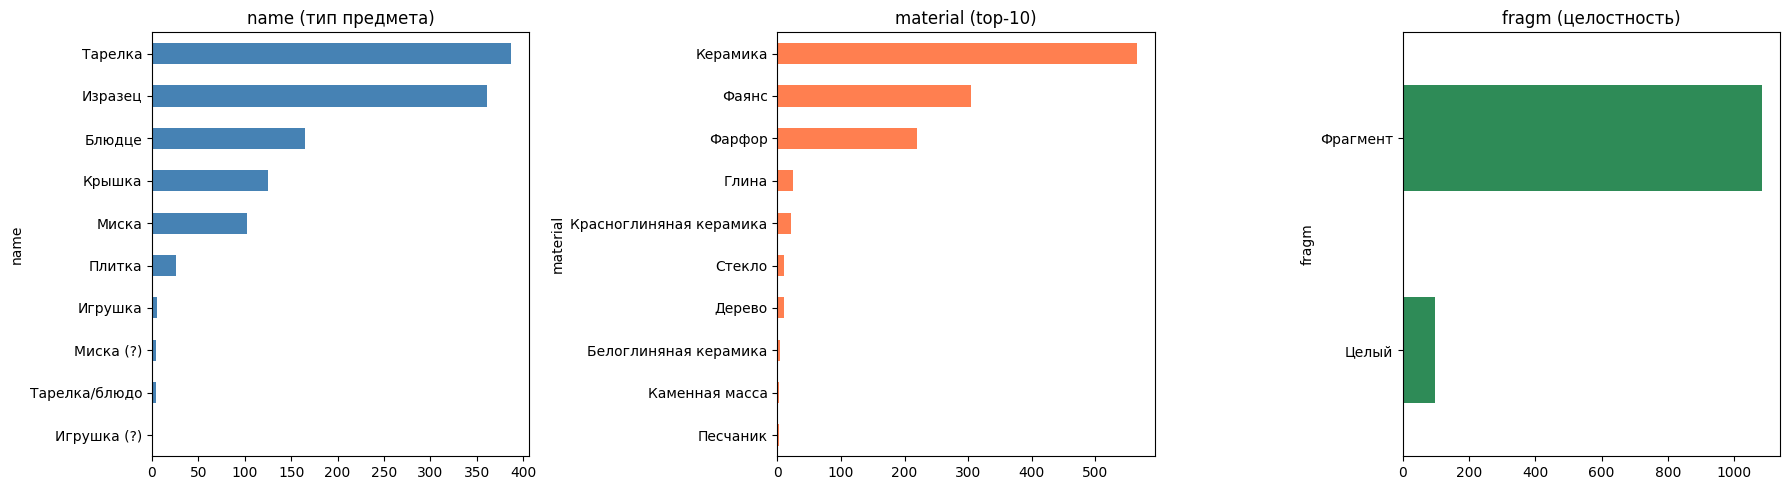

In [23]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# name
df["name"].value_counts().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("name (тип предмета)")
axes[0].invert_yaxis()

# material (top-10)
df["material"].value_counts().head(10).plot.barh(ax=axes[1], color="coral")
axes[1].set_title("material (top-10)")
axes[1].invert_yaxis()

# fragm
df["fragm"].value_counts().plot.barh(ax=axes[2], color="seagreen")
axes[2].set_title("fragm (целостность)")
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig("artifacts/figures/eda_field_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


Scanning 1180 images...


Silhouette scan final:   0%|          | 0/1180 [00:00<?, ?it/s]


=== Results ===
Total:       1180
Silhouettes: 13  (1.10%)


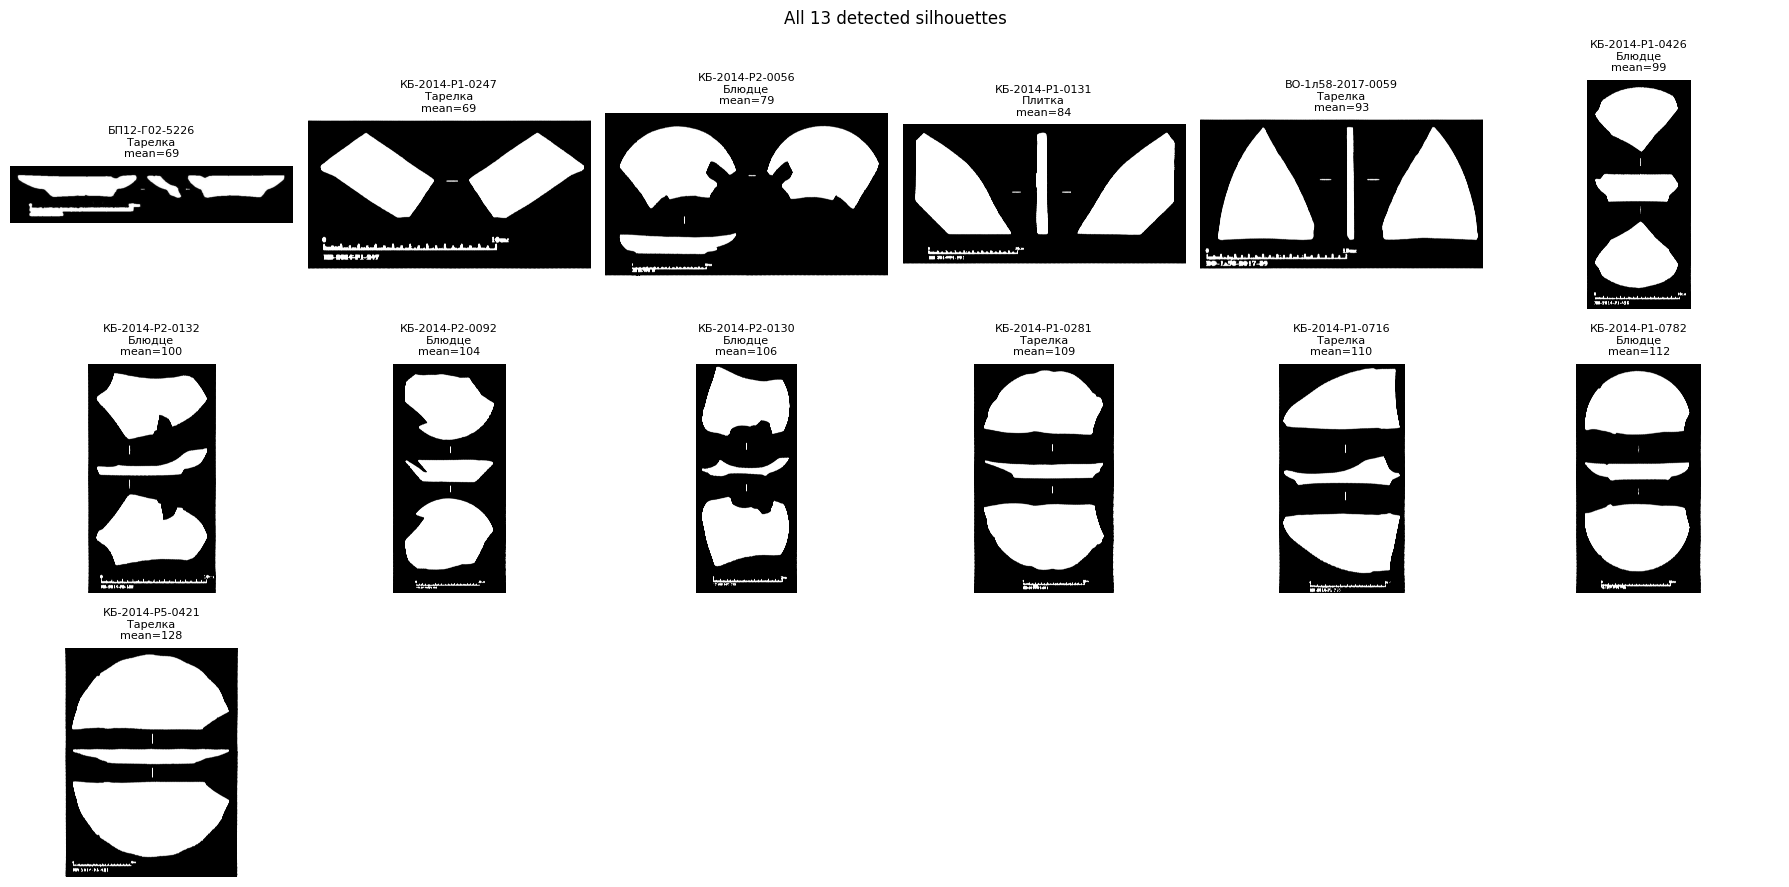


=== 13 silhouette codes ===
    "БП12-Г02-5226",
    "ВО-1л58-2017-0059",
    "КБ-2014-Р1-0131",
    "КБ-2014-Р1-0247",
    "КБ-2014-Р1-0281",
    "КБ-2014-Р1-0426",
    "КБ-2014-Р1-0716",
    "КБ-2014-Р1-0782",
    "КБ-2014-Р2-0056",
    "КБ-2014-Р2-0092",
    "КБ-2014-Р2-0130",
    "КБ-2014-Р2-0132",
    "КБ-2014-Р5-0421",

✓ Dropped 13 silhouettes. df now has 1167 rows.


In [24]:
Image.MAX_IMAGE_PIXELS = None

means = []
for p in tqdm(df["image_file"], desc="brightness scan"):
    try:
        with Image.open(p) as img:
            img.thumbnail((200, 200))
            means.append(float(np.asarray(img.convert("L")).mean()))
    except Exception:
        means.append(255.0)

df["mean_brightness"] = means
# silhouettes cluster below 130, real photos start at 175+; threshold 150 is in the gap
df["is_silhouette"] = (df["mean_brightness"] < 150).astype(int)

n_sil = df["is_silhouette"].sum()
print(f"detected silhouettes: {n_sil} / {len(df)} ({n_sil / len(df) * 100:.1f}%)")

sil_rows = df[df["is_silhouette"] == 1].sort_values("mean_brightness")
if len(sil_rows) > 0:
    n_show = len(sil_rows)
    n_cols  = 6
    n_rows  = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, (_, row) in zip(axes, sil_rows.iterrows()):
        try:
            ax.imshow(Image.open(row["image_file"]).convert("RGB"))
        except Exception:
            ax.text(0.5, 0.5, "load error", ha="center", va="center")
        ax.set_title(f"{row['code']}\nmean={row['mean_brightness']:.0f}", fontsize=8)
        ax.axis("off")
    for ax in axes[n_show:]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("artifacts/figures/eda_silhouettes.png", dpi=120, bbox_inches="tight")
    plt.show()

SILHOUETTE_CODES = set(sil_rows["code"].tolist())
print("silhouette codes:")
for c in sorted(SILHOUETTE_CODES):
    print(f"  {c}")

n_before = len(df)
df = df[df["is_silhouette"] == 0].drop(columns=["is_silhouette", "mean_brightness"])
df = df.reset_index(drop=True)
print(f"dropped {n_before - len(df)} silhouettes, {len(df)} rows remain")


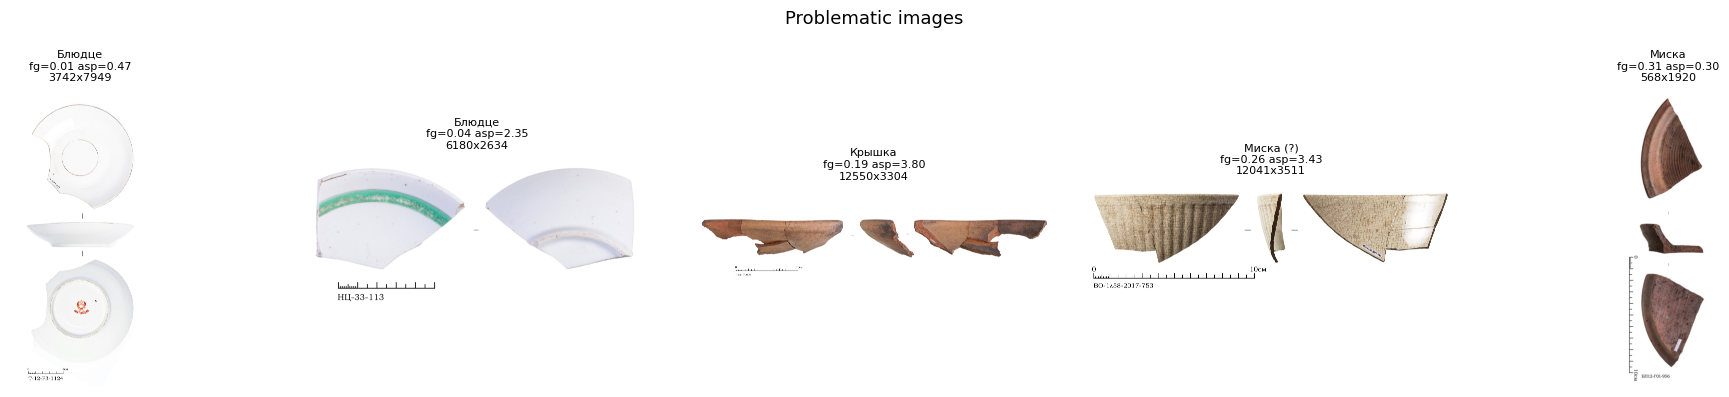

In [25]:
def show_problematic_images(df: pd.DataFrame, n: int = 5) -> None:
    """Show images with extreme aspect ratios or very small foreground."""
    candidates = df[df["image_file"].notna()].copy()

    stats = []
    for _, row in candidates.sample(min(200, len(candidates)), random_state=SEED + 2).iterrows():
        path = row["image_file"]
        try:
            with Image.open(path) as img:
                w, h = img.size
                arr = np.array(img.convert("RGB"))
                fg = (np.mean(arr, axis=2) <= 200).sum() / (w * h)
                stats.append({"code": row["code"], "image_file": row["image_file"],
                              "aspect": w / h, "fg_ratio": fg, "w": w, "h": h,
                              "name": row["name"], "material": row["material"]})
        except:
            pass

    sdf = pd.DataFrame(stats)

    problems = pd.concat([
        sdf.nsmallest(2, "fg_ratio"),
        sdf.nlargest(2, "aspect"),
        sdf.nsmallest(1, "w"),
    ]).drop_duplicates("code").head(n)

    fig, axes = plt.subplots(1, len(problems), figsize=(4 * len(problems), 4))
    if len(problems) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, problems.iterrows()):
        img = Image.open(row["image_file"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{row['name']}\nfg={row['fg_ratio']:.2f} asp={row['aspect']:.2f}\n{row['w']}x{row['h']}", fontsize=8)
        ax.axis("off")

    plt.suptitle("Problematic images", fontsize=13)
    plt.tight_layout()
    plt.savefig("artifacts/figures/eda_problematic.png", dpi=150, bbox_inches="tight")
    plt.show()

if df["image_file"].notna().any():
    show_problematic_images(df)
else:
    print("Skipping.")

In [ ]:
def classify_visual_mode(img_path: str, code: str) -> dict:
    """Pixel heuristics for visual mode classification.

    foreground_ratio: fraction of pixels with mean channel < 200
    bg_type:          corner brightness check (top-left + top-right 20%)
    has_scale_bar:    horizontal dark band in bottom 10% of image
    layout_mode:      multi_view / single_fragment / close_up
    """
    try:
        with Image.open(img_path) as img:
            arr = np.array(img.convert("RGB").resize((300, 300)), dtype=np.float32)

        fg_ratio = float((arr.mean(axis=2) < 200).mean())

        corners = np.concatenate([arr[:60, :60].reshape(-1, 3),
                                   arr[:60, 240:].reshape(-1, 3)])
        mc = corners.mean()
        bg_type = "white" if mc > 230 else ("light_gray" if mc > 180 else "other")

        dark_cols = (arr[270:].mean(axis=2) < 100).sum(axis=0)
        has_scale_bar = bool((dark_cols > 10).sum() > 50)

        with Image.open(img_path) as img:
            w, h = img.size
        aspect = w / h
        if fg_ratio <= 0.15:
            layout_mode = "close_up"
        elif 0.15 < fg_ratio < 0.65 and aspect > 1.6:
            layout_mode = "multi_view"
        else:
            layout_mode = "single_fragment"

        return {
            "code": code,
            "foreground_ratio": round(fg_ratio, 3),
            "bg_type": bg_type,
            "has_scale_bar": has_scale_bar,
            "layout_mode": layout_mode,
        }
    except Exception:
        return {"code": code, "foreground_ratio": None, "bg_type": None,
                "has_scale_bar": None, "layout_mode": None}


sample_vm = df[df["image_file"].notna()].sample(min(300, len(df)), random_state=SEED)
vm_records = [
    classify_visual_mode(row["image_file"], row["code"])
    for _, row in tqdm(sample_vm.iterrows(), total=len(sample_vm), desc="visual mode")
]
vm_df = pd.DataFrame(vm_records)

print(f"visual mode (n={len(vm_df)}):")
print(vm_df["layout_mode"].value_counts().to_string())
print()
print("background type:")
print(vm_df["bg_type"].value_counts().to_string())
print(f"\nhas scale bar: {vm_df['has_scale_bar'].sum()} / {len(vm_df)}")

df = df.merge(
    vm_df[["code", "foreground_ratio", "bg_type", "has_scale_bar", "layout_mode"]],
    on="code", how="left"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
vm_df["foreground_ratio"].hist(bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("foreground_ratio")
vm_df["layout_mode"].value_counts().plot.bar(ax=axes[1], color="coral")
axes[1].set_title("layout_mode")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("artifacts/figures/eda_visual_modes.png", dpi=150, bbox_inches="tight")
plt.show()


Короче прям проблемных картинок нету

ВЫВОДЫ

 - Сильный дисбаланс по name и fragm
 - Корпус содержит multi-view карточки (несколько ракурсов на одном холсте), close-up клейм и одиночные фрагменты. По ощущениям в основном multi-view.
 - Фон на всех картинках белый, часто есть линейка и инвентарный номер
 - Сильно варьируется соотношение сторон
 - FG ratio от 10 до 70, CenterCrop не сработает

# Структура описаний, выбор полей

In [26]:
print("=== 20 sample descriptions ===")
for i, d in enumerate(df["description"].sample(20, random_state=SEED)):
    print(f"{i+1:3d}. {d}")

=== 20 sample descriptions ===
  1. Миски красноглиняной профиля фр-т
  2. Изразца красноглиняного с белой поливой карниза фр-т
  3. Изразца красноглиняного с темно-серебристой поливой и орнаментом фр-т
  4. Блюдце фарфоровое с белой поливой снаружи и внутри с золотым линейным орнаментом и клеймом на донце фр-ое
  5. Крышки сосуда красноглиняного с прозрачной поливой снаружи фр-т
  6. Сосуда фаянсового с бежевой поливой снаружи и внутри ручка от крышки (либо часть рельефного декора ?) круглая, орнаментированная рельефными лепестками
  7. Тарелки фаянсовой с зеленой поливой снаружи и желтой внутри  венчика фр-т
  8. Тарелки фаянсовой с полихромной росписью края фр-т
  9. Изразца прямого красноглиняного с голубой поливой и голубым орнаментом "вазон" фр-т
 10. Миска светлоглиняная
 11. Изразец-перемычка красноглиняный с белой поливой и кобальтовой росписью цветами
 12. Тарелки фаянсовой края фр-ты
 13. Сосуда (тарелки ?) фаянсовой с белой поливой внутри и снаружи донца клейменого фр-т
 14

In [27]:
CANDIDATES = {
    "придонная_часть": r"придонн",
    "венчик":          r"венчик",
    "донце":           r"донц|донец",
    "стенка":          r"стенк",
    "край":            r"\bкра[яйёе]\b",
    "румпа":           r"румп",
    "карниз":          r"карниз",
    "крышка":          r"крышк",
    "ручка":           r"ручк",
    "профиль":         r"профил",
    "горлышко":        r"горлышк|горловин",
    "тулово":          r"тулов",
    "носик":           r"носик",
    "ножка":           r"ножк",
    "поддон":          r"поддон",
    "ушко":            r"ушк",
    "плечико":         r"плечик",
    "перемычка":       r"перемычк",
    "пояс-валик":      r"пояс[- ]валик",
    "скол":            r"\bскол\b",
}

hit_counts = {
    name: df["description"].str.lower().str.contains(pat, regex=True, na=False).sum()
    for name, pat in CANDIDATES.items()
}

print("part candidate hit counts:")
for name, cnt in sorted(hit_counts.items(), key=lambda x: -x[1]):
    print(f"  {name:20s}  {cnt}")

print()
for name, pat in CANDIDATES.items():
    if hit_counts[name] < 10:
        continue
    matches = df[df["description"].str.lower().str.contains(pat, regex=True, na=False)]
    samples = matches["description"].sample(min(3, len(matches)), random_state=42).tolist()
    print(f"[{name}]  {hit_counts[name]} hits")
    for s in samples:
        print(f"  {s[:140]}")
    print()

combined_pat = "|".join(CANDIDATES.values())
no_part = ~df["description"].str.lower().str.contains(combined_pat, regex=True, na=False)
print(f"descriptions with no part match: {no_part.sum()} / {len(df)} ({no_part.mean()*100:.1f}%)")
print()
for s in df[no_part]["description"].sample(min(10, no_part.sum()), random_state=42):
    print(f"  {s[:140]}")


=== Part-candidate hit counts ===
  фрагмент (дубль)    :   875
  профиль             :   232
  донце               :   152
  крышка              :   125
  венчик              :   112
  край                :    95
  румпа               :    88
  придонная_часть     :    38
  перемычка           :    33
  карниз              :    25
  ручка               :    21
  стенка              :    14
  ушко                :     7
  пояс-валик          :     6
  ножка               :     2
  скол                :     2
  горлышко            :     0
  тулово              :     0
  носик               :     0
  поддон              :     0
  плечико             :     0

=== Sample descriptions per part ===

[придонная_часть] (38 hits)
   Тарелки фаянсовой придонной части с клеймом фр-т
   Тарелки фаянсовой с синей монохромной росписью внутри с клеймом снаружи придонной части фр-т
   Тарелки белоглиняной с белой поливой снаружи и голубым орнаментом по белой поливе внутри придонной части фр-т

[венчик

Total with 'профиль': 232


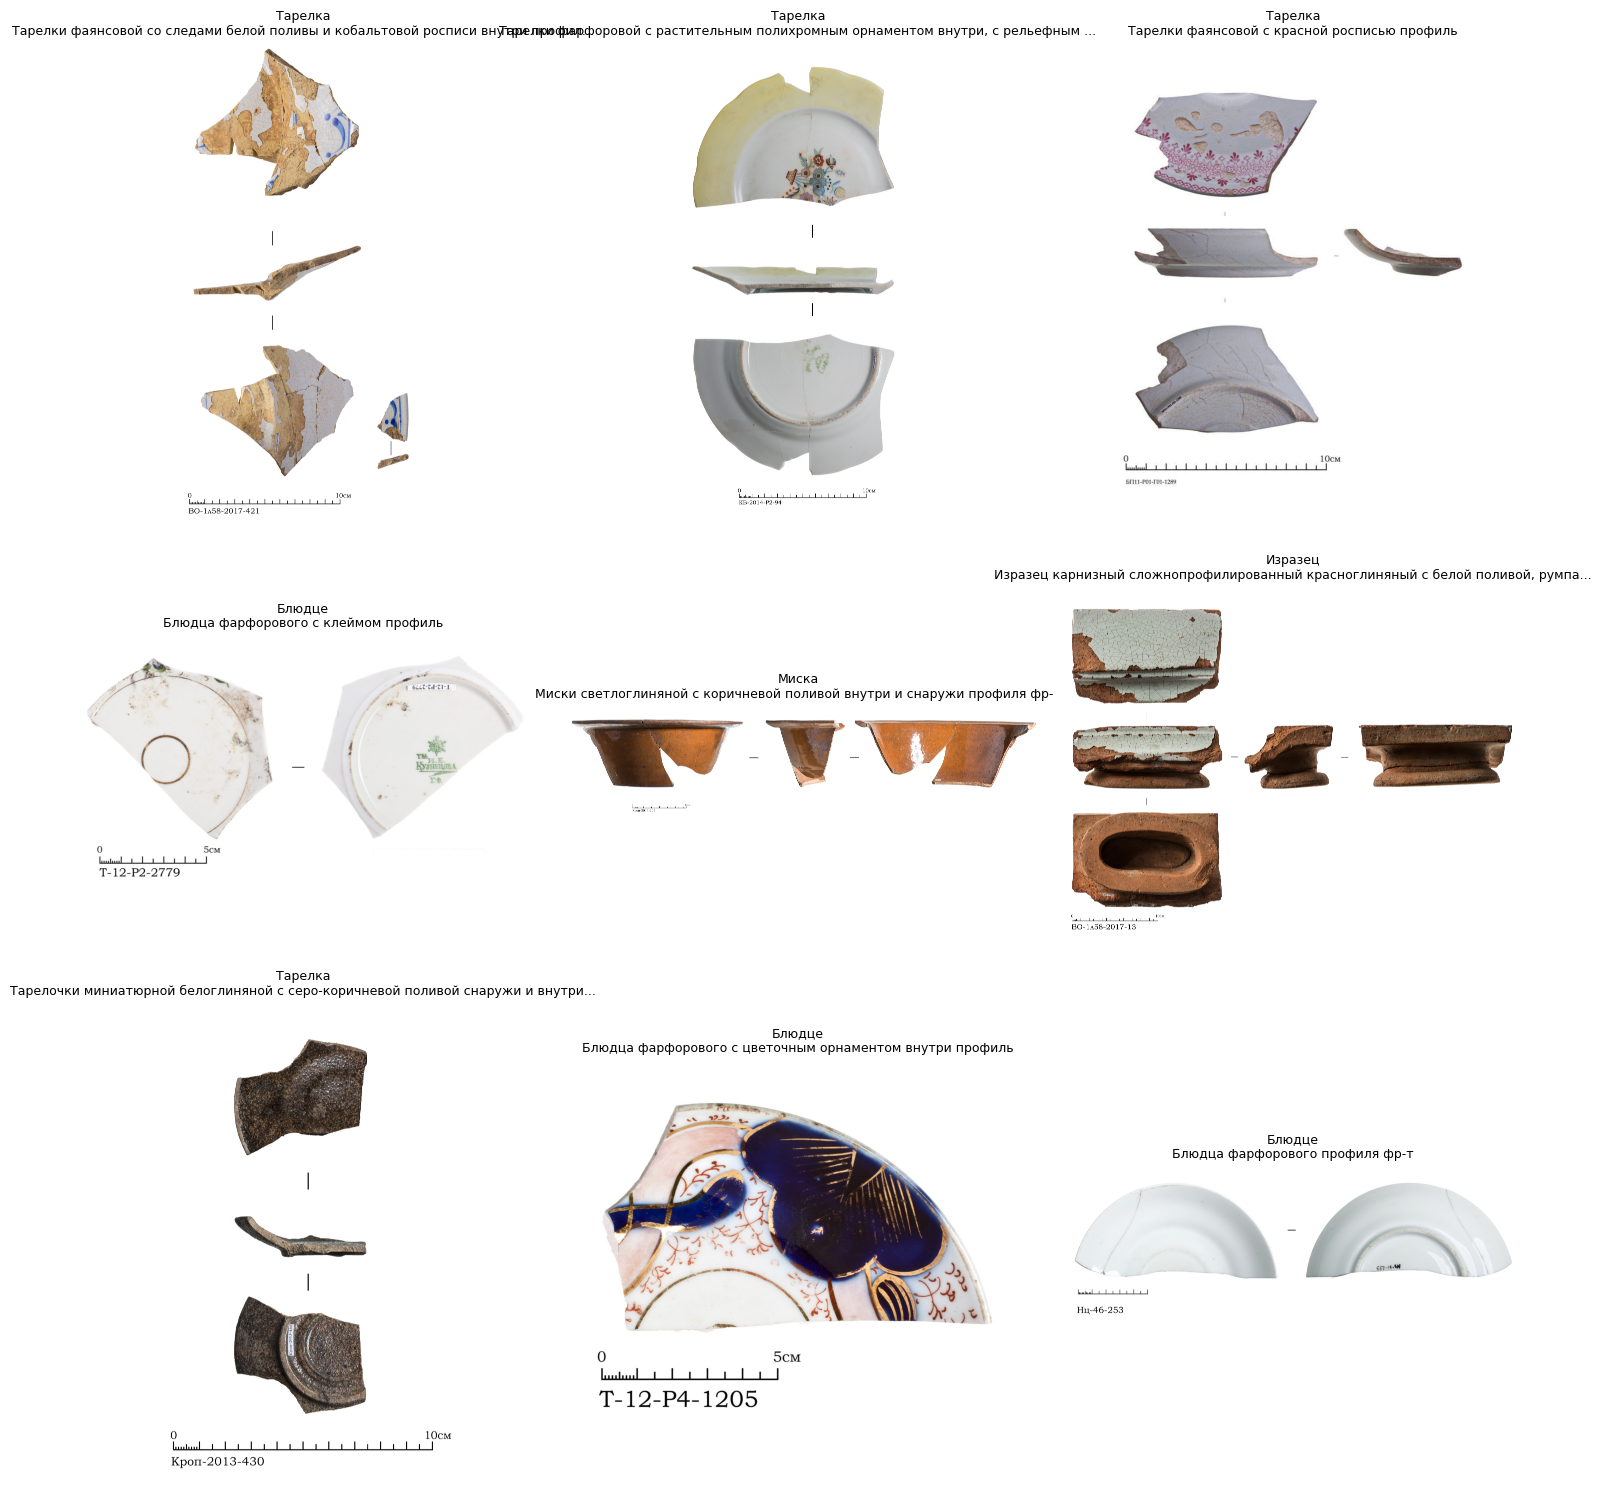

In [28]:
# Show image examples where description contains 'профиль'
mask = df["description"].str.lower().str.contains(r"профил", regex=True, na=False)
print(f"Total with 'профиль': {mask.sum()}")

sample = df[mask].sample(min(9, mask.sum()), random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    try:
        img = Image.open(row["image_file"]).convert("RGB")
        ax.imshow(img)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {e}", ha="center", va="center", transform=ax.transAxes)

    # Wrap description for title
    desc = row["description"]
    if len(desc) > 80:
        desc = desc[:77] + "..."
    ax.set_title(f"{row['name']}\n{desc}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("artifacts/figures/eda_profil_examples.png", dpi=120, bbox_inches="tight")
plt.show()

In [29]:
PART_PATTERNS = [
    ("придонная_часть", r"придонн"),
    ("перемычка",       r"перемычк"),
    ("венчик",          r"венчик"),
    ("донце",           r"донц|донец"),
    ("край",            r"\bкра[яй]\b"),
    ("румпа",           r"румп"),
    ("карниз",          r"карниз"),
    ("крышка",          r"крышк"),
    ("ручка",           r"ручк"),
    ("стенка",          r"стенк"),
]

def extract_part(description: str) -> str:
    """Extract artifact part from free-text description via ordered regex matching.

    More specific patterns come first to avoid false matches
    (e.g. 'придонная_часть' before 'донце').
    Returns 'не_указано' if nothing matches.
    """
    desc_lower = str(description).lower()
    for name, pattern in PART_PATTERNS:
        if re.search(pattern, desc_lower):
            return name
    return "не_указано"

df["part"] = df["description"].apply(extract_part)

n_with = (df["part"] != "не_указано").sum()
print(df["part"].value_counts().to_string())
print(f"\nwith part: {n_with} / {len(df)} ({n_with / len(df) * 100:.1f}%)")


=== Extracted part distribution ===
part
не_указано         511
донце              150
крышка             113
венчик             112
край                95
румпа               84
придонная_часть     38
перемычка           33
карниз              16
стенка              12
ручка                3

With part specified:  656 / 1167 (56.2%)
Без указания части:   511


Берем:
- name - форма, размер, морфология легко видны из картинки, но есть несколько неоднозначных классов (Миска (?) и т.п.)
- fragm - легко видно по картинке, целый артефакт или фрагмент, но сильный дисбаланс классов
- material - Частично можно определить по картинке, будем классифицировать веротяностно и нормализовывать
- part - видно по морфологии


In [ ]:
field_candidates = pd.DataFrame([
    {
        "field":           "name",
        "visible":         "shape, size, morphology are unambiguous",
        "target_type":     "single-label",
        "n_classes":       df["name"].nunique(),
        "missing_%":       round(df["name"].isna().mean() * 100, 1),
        "risk":            "ambiguous labels: 'Миска (?)', 'Тарелка/блюдо'",
        "include":         "yes",
    },
    {
        "field":           "fragm",
        "visible":         "whole vs fragment is directly observable",
        "target_type":     "binary",
        "n_classes":       2,
        "missing_%":       round(df["fragm"].isna().mean() * 100, 1),
        "risk":            "strong imbalance (~90% fragments)",
        "include":         "yes",
    },
    {
        "field":           "material",
        "visible":         "color, texture, glaze give signal",
        "target_type":     "single-label (probabilistic)",
        "n_classes":       df["material"].nunique(),
        "missing_%":       round(df["material"].isna().mean() * 100, 1),
        "risk":            "ceramic subtypes look similar; predict probabilistically",
        "include":         "yes",
    },
    {
        "field":           "part (from description)",
        "visible":         "rim/base/wall morphology is visible",
        "target_type":     "single-label + missing mask",
        "n_classes":       10,
        "missing_%":       round(
            (~df["description"].str.lower().str.contains(
                r"придонн|венчик|донц|стенк|профил|румп|карниз|крышк|ручк",
                regex=True, na=False)).mean() * 100, 1),
        "risk":            "many descriptions do not mention part explicitly",
        "include":         "yes (with mask)",
    },
    {
        "field":           "function",
        "visible":         "no — requires cultural context",
        "target_type":     "-",
        "n_classes":       "-",
        "missing_%":       "-",
        "risk":            "not extractable from image",
        "include":         "no",
    },
    {
        "field":           "dating / cultural affiliation",
        "visible":         "no — typological labels need expert context",
        "target_type":     "-",
        "n_classes":       "-",
        "missing_%":       "-",
        "risk":            "shortcut risk: model may read inventory label from card",
        "include":         "no",
    },
    {
        "field":           "fine typological labels",
        "visible":         "no — requires specialized annotation",
        "target_type":     "-",
        "n_classes":       "-",
        "missing_%":       "-",
        "risk":            "label noise too high for baseline",
        "include":         "no",
    },
])

pd.set_option("display.max_colwidth", 55)
print(field_candidates.to_string(index=False))


# Нормализация словарей и сбор целевых колонок


In [30]:
NAME_MAP = {
    "Изразец":         "изразец",
    "Тарелка":         "тарелка",
    "Блюдце":          "блюдце",
    "Крышка":          "крышка",
    "Миска":           "миска",
    "Плитка":          "плитка",
    "Миска (?)":       "миска",
    "Тарелка/блюдо":   "тарелка",
    "Игрушка":         "другое",
    "Игрушка (?)":     "другое",
    "Игрушка ёлочная": "другое",
    "Чемодан":         "другое",
}

df["name_raw"]  = df["name"]
df["name_norm"] = df["name"].map(NAME_MAP)

unmapped = df[df["name_norm"].isna()]["name"].unique()
if len(unmapped):
    print(f"unmapped names (-> 'другое'): {unmapped}")
df["name_norm"] = df["name_norm"].fillna("другое")

print(df["name_norm"].value_counts().to_string())


=== name_norm distribution ===
name_norm
тарелка    385
изразец    361
блюдце     159
крышка     125
миска      106
плитка      25
другое       6


In [31]:
MATERIAL_MAP = {
    "Керамика":                "керамика",
    "Красноглиняная керамика": "керамика",
    "Белоглиняная керамика":   "керамика",
    "Светлоглиняная керамика": "керамика",
    "Серолощеная керамика":    "керамика",
    "Глина":                   "керамика",  # treated as ceramic in this corpus
    "Фарфор":                  "фарфор",
    "Фаянс":                   "фаянс",
    "Стекло":                  "стекло",
    "Каменная масса":          "другое",
    "Дерево":                  "другое",
    "Металл":                  "другое",
    "Железо":                  "другое",
    "Бронза":                  "другое",
    "Белый металл":            "другое",
    "Камень":                  "другое",
    "Песчаник":                "другое",
    "Сланец":                  "другое",
    "Мрамор":                  "другое",
    "Гранит":                  "другое",
    "Кожа":                    "другое",
    "Пластмасса":              "другое",
    "Резина":                  "другое",
    "Основание - бетон, покрытие - композитный материал": "другое",
    "Изразец":                 "керамика",  # raw label leak in source data
}

df["material_raw"]  = df["material"]
df["material_norm"] = df["material"].map(MATERIAL_MAP)

unmapped = df[df["material_norm"].isna()]["material"].unique()
if len(unmapped):
    print(f"unmapped materials (-> 'другое'): {unmapped}")
df["material_norm"] = df["material_norm"].fillna("другое")

print(df["material_norm"].value_counts().to_string())


=== material_norm distribution ===
material_norm
керамика    618
фаянс       301
фарфор      211
другое       26
стекло       11


In [32]:
PART_MAP = {
    "придонная_часть": "придонная_часть",
    "перемычка":       "перемычка",
    "венчик":          "венчик",
    "донце":           "донце",
    "край":            "край",
    "румпа":           "румпа",
    "карниз":          "карниз",
    "крышка":          "крышка",
    "стенка":          "стенка",
    "ручка":           "другое",   # too few examples to train reliably
    "не_указано":      "не_указано",
}

df["part_norm"]       = df["part"].map(PART_MAP).fillna("другое")
df["part_is_missing"] = (df["part_norm"] == "не_указано").astype(int)

print(df["part_norm"].value_counts().to_string())
print(f"\nmissing part (mask=0): {df['part_is_missing'].sum()}")


=== part_norm distribution ===
part_norm
не_указано         511
донце              150
крышка             113
венчик             112
край                95
румпа               84
придонная_часть     38
перемычка           33
карниз              16
стенка              12
другое               3

Missing part (mask=0): 511


In [33]:
df["fragm_raw"]  = df["fragm"]
df["fragm_norm"] = df["fragm"].map({"Фрагмент": "фрагмент", "Целый": "целый"})

n_null = df["fragm_norm"].isna().sum()
if n_null:
    print(f"{n_null} rows with null fragm — dropping")
    df = df[df["fragm_norm"].notna()].reset_index(drop=True)

print(df["fragm_norm"].value_counts().to_string())


=== fragm_norm distribution ===
fragm_norm
фрагмент    1072
целый         95


In [34]:
import json

TARGET_FIELDS = ["name_norm", "fragm_norm", "material_norm", "part_norm"]

label_encoders: dict[str, dict[str, int]] = {}
label_decoders: dict[str, dict[int, str]] = {}

for field in TARGET_FIELDS:
    unique_vals = sorted(df[field].dropna().unique())
    encoder = {v: i for i, v in enumerate(unique_vals)}
    decoder = {i: v for v, i in encoder.items()}
    label_encoders[field] = encoder
    label_decoders[field] = decoder
    df[f"{field}_idx"] = df[field].map(encoder)

    print(f"{field}: {len(encoder)} classes")
    for v, i in encoder.items():
        cnt = (df[field] == v).sum()
        print(f"  [{i}] {v:20s}  {cnt:5d}  ({cnt / len(df) * 100:5.1f}%)")
    print()

df.to_csv("data/interim/df_prepared.csv", index=False)
with open("data/interim/label_encoders.json", "w", encoding="utf-8") as f:
    json.dump(label_encoders, f, ensure_ascii=False, indent=2)



name_norm: 7 classes
  [0] блюдце                 159 ( 13.6%) ██████
  [1] другое                   6 (  0.5%) 
  [2] изразец                361 ( 30.9%) ███████████████
  [3] крышка                 125 ( 10.7%) █████
  [4] миска                  106 (  9.1%) ████
  [5] плитка                  25 (  2.1%) █
  [6] тарелка                385 ( 33.0%) ████████████████

fragm_norm: 2 classes
  [0] фрагмент              1072 ( 91.9%) █████████████████████████████████████████████
  [1] целый                   95 (  8.1%) ████

material_norm: 5 classes
  [0] другое                  26 (  2.2%) █
  [1] керамика               618 ( 53.0%) ██████████████████████████
  [2] стекло                  11 (  0.9%) 
  [3] фарфор                 211 ( 18.1%) █████████
  [4] фаянс                  301 ( 25.8%) ████████████

part_norm: 11 classes
  [0] венчик                 112 (  9.6%) ████
  [1] донце                  150 ( 12.9%) ██████
  [2] другое                   3 (  0.3%) 
  [3] карниз         

In [ ]:
# name: raw label contains '(?)'
df["name_is_uncertain"] = df["name_raw"].str.contains(r"\(\?\)", regex=True, na=False).astype(int)

# material: raw label has slashes/parentheses, or falls into catch-all 'другое'
df["material_is_uncertain"] = (
    df["material_raw"].str.contains(r"[/(]", regex=True, na=False)
    | (df["material_norm"] == "другое")
).astype(int)

# part: uncertain when no regex pattern matched
df["part_is_uncertain"]  = df["part_is_missing"].copy()
df["fragm_is_uncertain"] = 0

for col in ["name_is_uncertain", "material_is_uncertain",
            "part_is_uncertain", "fragm_is_uncertain"]:
    print(f"{col}: {df[col].sum()} / {len(df)} ({df[col].mean() * 100:.1f}%)")


In [35]:
KEEP_COLUMNS = [
    "code", "code_norm", "image_file", "group_key", "description",
    # raw labels kept for error analysis
    "name_raw", "material_raw", "fragm_raw",
    # normalized labels
    "name_norm", "fragm_norm", "material_norm", "part_norm",
    # model targets
    "name_norm_idx", "fragm_norm_idx", "material_norm_idx", "part_norm_idx",
    # masks and uncertainty flags
    "part_is_missing",
    "name_is_uncertain", "material_is_uncertain", "part_is_uncertain", "fragm_is_uncertain",
    # visual mode features (populated for sample subset)
    "foreground_ratio", "bg_type", "has_scale_bar", "layout_mode",
]

KEEP_COLUMNS = [c for c in KEEP_COLUMNS if c in df.columns]
dropped = [c for c in df.columns if c not in KEEP_COLUMNS]
df = df[KEEP_COLUMNS].copy()

print(f"dropped {len(dropped)} columns: {dropped}")
print()
print(df.dtypes.to_string())
print(f"\nshape: {df.shape}")

df.to_csv("data/interim/df_prepared.csv", index=False)


Dropped 18 columns: ['name', 'material', 'fragm', 'size', 'cultlayer', 'execorg', 'survyear', 'memo', 'source', 'image_source', 'part', 'name_raw', 'name_norm', 'material_raw', 'material_norm', 'part_norm', 'fragm_raw', 'fragm_norm']

Final columns (10):
code                 object
code_norm            object
image_file           object
group_key            object
description          object
name_norm_idx         int64
fragm_norm_idx        int64
material_norm_idx     int64
part_norm_idx         int64
part_is_missing       int64

Shape: (1167, 10)

✓ Re-saved data/interim/df_prepared.csv (clean)


# Шаблон auto description

In [36]:
!pip install pymorphy3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 68.6 MB/s eta 0:00:00


In [37]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

CONFIDENCE_THRESHOLDS = {
    "name_norm":     0.40,
    "material_norm": 0.50,
    "part_norm":     0.50,
    "fragm_norm":    0.30,
}

MATERIAL_ADJ = {
    "керамика": "керамический",
    "фарфор":   "фарфоровый",
    "фаянс":    "фаянсовый",
    "стекло":   "стеклянный",
    "другое":   None,
}

_morph_cache: dict[tuple, str] = {}

def agree_adjective(adj: str, noun: str) -> str:
    """Agree adjective with noun gender/number via pymorphy3.
    Falls back to masculine form on failure.
    """
    key = (adj, noun)
    if key in _morph_cache:
        return _morph_cache[key]
    try:
        noun_parse = morph.parse(noun)[0]
        adj_parse  = morph.parse(adj)[0]
        grammemes  = {noun_parse.tag.gender, noun_parse.tag.number}
        grammemes.discard(None)
        inflected = adj_parse.inflect(grammemes)
        result = inflected.word if inflected else adj
    except Exception:
        result = adj
    _morph_cache[key] = result
    return result


def build_auto_description(
    pred_name: str,     conf_name: float,
    pred_material: str, conf_material: float,
    pred_part: str,     conf_part: float,
    pred_fragm: str,    conf_fragm: float,
    thresholds: dict = CONFIDENCE_THRESHOLDS,
) -> str:
    """Assemble auto_description from predicted fields and confidence scores.

    Template order: name [material_adj], [part], [fragm]
    Fields are omitted when confidence is below threshold.
    """
    name_word = pred_name if conf_name >= thresholds["name_norm"] else "предмет"

    material_adj = None
    if conf_material >= thresholds["material_norm"] and pred_material != "другое":
        base_adj = MATERIAL_ADJ.get(pred_material)
        if base_adj:
            material_adj = agree_adjective(base_adj, name_word)

    name_chunk = name_word.capitalize()
    if material_adj:
        name_chunk = f"{name_chunk} {material_adj}"

    parts = [name_chunk]
    if conf_part >= thresholds["part_norm"] and pred_part not in {"не_указано", "другое"}:
        parts.append(pred_part.replace("_", " "))
    if conf_fragm >= thresholds["fragm_norm"]:
        parts.append(pred_fragm)

    return ", ".join(parts)


In [38]:
test_cases = [
    # (name, conf_name, material, conf_mat, part, conf_part, fragm, conf_fragm)
    ("изразец",  0.95, "керамика", 0.88, "румпа",      0.75, "фрагмент", 0.99),
    ("тарелка",  0.80, "фарфор",   0.72, "донце",      0.65, "фрагмент", 0.97),
    ("блюдце",   0.85, "фаянс",    0.60, "венчик",     0.55, "фрагмент", 0.92),
    ("крышка",   0.90, "фаянс",    0.60, "не_указано", 0.30, "целый",    0.85),
    ("миска",    0.70, "керамика", 0.55, "край",       0.60, "фрагмент", 0.95),
    ("тарелка",  0.25, "керамика", 0.30, "край",       0.20, "фрагмент", 0.20),  # all low
    ("блюдце",   0.80, "фарфор",   0.30, "донце",      0.70, "фрагмент", 0.90),  # material below threshold
    ("изразец",  0.95, "керамика", 0.80, "не_указано", 0.50, "фрагмент", 0.99),  # part missing
]

for name, cn, mat, cm, part, cp, fragm, cf in test_cases:
    desc   = build_auto_description(name, cn, mat, cm, part, cp, fragm, cf)
    inputs = f"{name}({cn:.2f}) {mat}({cm:.2f}) {part}({cp:.2f}) {fragm}({cf:.2f})"
    print(f"{inputs}")
    print(f"  -> {desc}")
    print()


=== auto_description template test ===

  изразец(0.95) керамика(0.88) румпа(0.75) фрагмент(0.99)
  → Изразец керамический, румпа, фрагмент

  тарелка(0.80) фарфор(0.72) донце(0.65) фрагмент(0.97)
  → Тарелка фарфоровая, донце, фрагмент

  блюдце(0.85) фаянс(0.60) венчик(0.55) фрагмент(0.92)
  → Блюдце фаянсовое, венчик, фрагмент

  крышка(0.90) фаянс(0.60) не_указано(0.30) целый(0.85)
  → Крышка фаянсовая, целый

  миска(0.70) керамика(0.55) край(0.60) фрагмент(0.95)
  → Миска керамическая, край, фрагмент

  тарелка(0.25) керамика(0.30) край(0.20) фрагмент(0.20)
  → Предмет

  блюдце(0.80) фарфор(0.30) донце(0.70) фрагмент(0.90)
  → Блюдце, донце, фрагмент

  изразец(0.95) керамика(0.80) не_указано(0.50) фрагмент(0.99)
  → Изразец керамический, фрагмент



# Train\test\val split

Сплитим на 70\15\15

Стратегия:

- Группируем df по group_key — получаем по одной строке на группу.
- Строим strat_key для каждой группы — комбинация из доминирующих (mode) значений целевых полей. Это "паспорт" группы.
- Редкие strat_key (единственная группа с такой комбинацией) мёрджим в rare — без этого stratified split падает.
- StratifiedShuffleSplit на группах (не на строках). Это балансирует распределение strat_key между train/val/test на уровне групп.
- Поиск по seeds — 300 попыток, лучшая по KL+proportion+coverage.

In [39]:
from sklearn.model_selection import StratifiedShuffleSplit

group_df = df.groupby("group_key").agg({
    f"{f}_idx": lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else -1
    for f in TARGET_FIELDS
}).reset_index()

group_df["strat_key"] = (
    group_df["name_norm_idx"].astype(str) + "_" +
    group_df["material_norm_idx"].astype(str) + "_" +
    group_df["fragm_norm_idx"].astype(str)
)
group_df["n_items"] = group_df["group_key"].map(df["group_key"].value_counts())

print(f"groups: {len(group_df)},  unique strat keys: {group_df['strat_key'].nunique()}")
print()
print(group_df["n_items"].describe().round(1).to_string())

# strat keys with only one group can't be stratified — merge into 'rare'
rare_keys = group_df["strat_key"].value_counts()
rare_keys = rare_keys[rare_keys < 2].index
print(f"\nrare strat keys (1 group): {len(rare_keys)} -> merged into 'rare'")
group_df.loc[group_df["strat_key"].isin(rare_keys), "strat_key"] = "rare"
print(f"final strat keys: {group_df['strat_key'].nunique()}")


Total groups: 72
Unique strat keys: 15

Group size stats:
count     72.0
mean      16.2
std       26.4
min        1.0
25%        2.0
50%        6.0
75%       19.5
max      175.0

Rare strat keys (1 group only): 6 → merged into 'rare'
Final unique strat keys: 10

Top strat keys:
strat_key
2_1_0    34
6_1_0     8
rare      6
6_4_0     5
0_3_0     5
6_3_0     4
3_3_0     3
4_1_0     3
5_1_1     2
3_1_0     2


In [40]:
TARGET_PROPS = {"train": 0.70, "val": 0.15, "test": 0.15}

def search_split(group_df: pd.DataFrame, df: pd.DataFrame, n_trials: int = 100):
    """Search over random seeds for the split that minimises:
      1. deviation from target proportions
      2. KL divergence of class distributions between train and val/test
      3. penalty for any class missing from a split
    """
    def score(split_series):
        props    = {s: (split_series == s).mean() for s in ["train", "val", "test"]}
        prop_err = sum((props[s] - TARGET_PROPS[s]) ** 2 for s in props) * 100

        cls_err = 0.0
        for field in TARGET_FIELDS:
            idx_col     = f"{field}_idx"
            all_classes = sorted(df[idx_col].dropna().unique())
            def dist(mask):
                return np.array([((df[idx_col] == c) & mask).sum()
                                  for c in all_classes], dtype=float)
            p_tr = dist(split_series == "train") + 1e-8
            p_va = dist(split_series == "val")   + 1e-8
            p_te = dist(split_series == "test")  + 1e-8
            p_tr /= p_tr.sum(); p_va /= p_va.sum(); p_te /= p_te.sum()
            cls_err += float((p_tr * np.log(p_tr / p_va)).sum())
            cls_err += float((p_tr * np.log(p_tr / p_te)).sum())
        cls_err /= len(TARGET_FIELDS) * 2

        missing_penalty = 0
        for field in TARGET_FIELDS:
            idx_col     = f"{field}_idx"
            all_classes = set(df[idx_col].dropna().unique())
            for s in ["train", "val", "test"]:
                if all_classes - set(df[split_series == s][idx_col].dropna().unique()):
                    missing_penalty += 1

        return prop_err + cls_err + missing_penalty * 10, props, missing_penalty

    best = None
    for trial in range(n_trials):
        try:
            sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=trial)
            tv_g_idx, test_g_idx = next(sss1.split(group_df, group_df["strat_key"]))
        except ValueError:
            continue
        tv_df = group_df.iloc[tv_g_idx]
        try:
            sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.176, random_state=trial)
            train_g_idx, val_g_idx = next(sss2.split(tv_df, tv_df["strat_key"]))
        except ValueError:
            continue
        train_groups = set(tv_df.iloc[train_g_idx]["group_key"])
        val_groups   = set(tv_df.iloc[val_g_idx]["group_key"])
        test_groups  = set(group_df.iloc[test_g_idx]["group_key"])
        split_series = df["group_key"].map(
            lambda g: "train" if g in train_groups
                      else "val" if g in val_groups
                      else "test" if g in test_groups
                      else None
        )
        sc, props, miss = score(split_series)
        if best is None or sc < best[0]:
            best = (sc, trial, split_series, props, miss)
    return best


best_score, best_trial, best_split, best_props, miss = search_split(group_df, df, n_trials=1000)
df["split"] = best_split
SPLIT_SEED  = best_trial

print(f"best split: trial={best_trial}  score={best_score:.4f}  missing-class issues={miss}")
for s in ["train", "val", "test"]:
    actual = best_props[s]
    print(f"  {s}: {actual * 100:.1f}%  (target {TARGET_PROPS[s] * 100:.0f}%)")



=== Best split (trial=486, score=0.3211) ===
  train:  66.3% (target 70%, dev -3.7%)
  val  :  18.0% (target 15%, dev +3.0%)
  test :  15.7% (target 15%, dev +0.7%)
  Missing-class issues: 0


Train ∩ Val:  0
Train ∩ Test: 0
Val ∩ Test:   0
✓ Zero group overlap

=== Class coverage ===
 All classes present in all splits


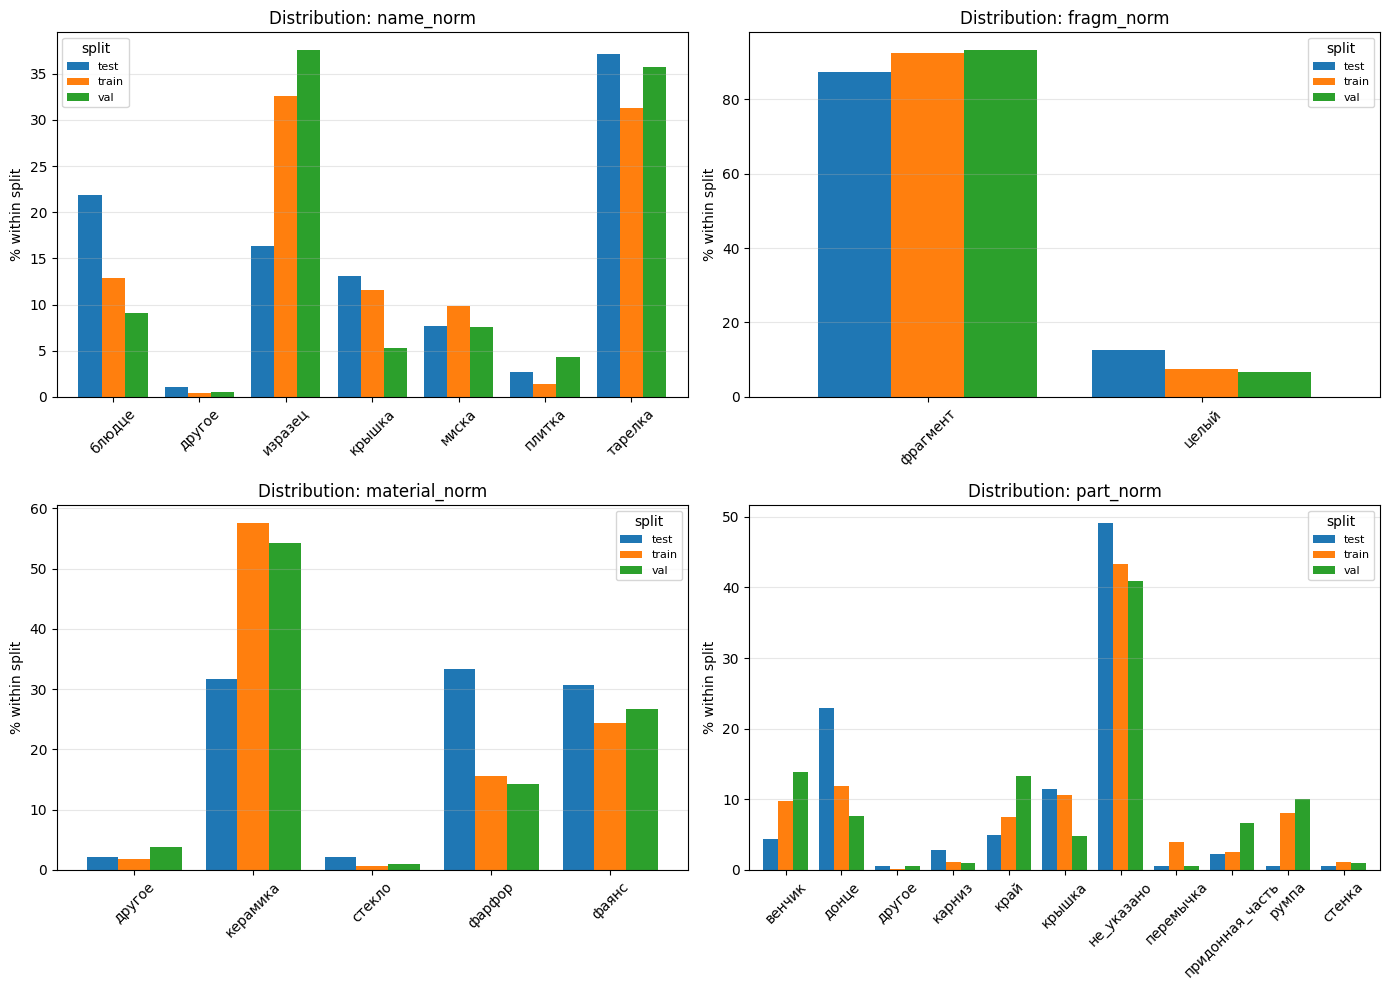

In [41]:
train_groups = set(df[df["split"] == "train"]["group_key"])
val_groups   = set(df[df["split"] == "val"]["group_key"])
test_groups  = set(df[df["split"] == "test"]["group_key"])

print(f"train & val overlap:  {len(train_groups & val_groups)}")
print(f"train & test overlap: {len(train_groups & test_groups)}")
print(f"val & test overlap:   {len(val_groups & test_groups)}")
assert len(train_groups & val_groups)  == 0
assert len(train_groups & test_groups) == 0
assert len(val_groups & test_groups)   == 0

issues = 0
for field in TARGET_FIELDS:
    idx_col     = f"{field}_idx"
    all_classes = set(df[idx_col].dropna().unique())
    for s in ["train", "val", "test"]:
        missing = all_classes - set(df[df["split"] == s][idx_col].dropna().unique())
        if missing:
            names = [label_decoders[field][c] for c in missing]
            print(f"missing in {field}/{s}: {names}")
            issues += 1
if issues == 0:
    print("all classes present in all splits")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, field in zip(axes.flat, TARGET_FIELDS):
    idx_col  = f"{field}_idx"
    decoder  = label_decoders[field]
    counts   = df.groupby("split")[idx_col].value_counts().unstack(fill_value=0)
    pcts     = counts.div(counts.sum(axis=1), axis=0) * 100
    pcts.columns = [decoder[c] for c in pcts.columns]
    pcts.T.plot.bar(ax=ax, rot=45, width=0.8)
    ax.set_title(field)
    ax.set_ylabel("% within split")
    ax.legend(title="split", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("artifacts/figures/split_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

df[["code", "split"]].to_csv("splits/split_stratified.csv", index=False)
df.to_csv("data/interim/df_prepared.csv", index=False)


In [ ]:
print("3 largest groups (all rows stay in one split):")
example_groups = (
    df.groupby("group_key").size()
      .sort_values(ascending=False)
      .head(3).index.tolist()
)
for gk in example_groups:
    rows = df[df["group_key"] == gk][["code", "name_norm", "split"]].reset_index(drop=True)
    print(f"  group_key={gk!r}  split={rows['split'].unique()}")
    print(rows.to_string(index=False))
    print()

# reproducibility check
from sklearn.model_selection import StratifiedShuffleSplit as _SSS

def _make_split(seed: int, gdf: pd.DataFrame, ddf: pd.DataFrame):
    sss1 = _SSS(n_splits=1, test_size=0.15,  random_state=seed)
    tv_idx, te_idx = next(sss1.split(gdf, gdf["strat_key"]))
    tv  = gdf.iloc[tv_idx]
    sss2 = _SSS(n_splits=1, test_size=0.176, random_state=seed)
    tr_idx, va_idx = next(sss2.split(tv, tv["strat_key"]))
    tr_g = set(tv.iloc[tr_idx]["group_key"])
    va_g = set(tv.iloc[va_idx]["group_key"])
    te_g = set(gdf.iloc[te_idx]["group_key"])
    return ddf["group_key"].map(
        lambda g: "train" if g in tr_g else "val" if g in va_g else "test"
    )

run1 = _make_split(SPLIT_SEED, group_df, df)
run2 = _make_split(SPLIT_SEED, group_df, df)
assert (run1 == run2).all(), "split is not reproducible"
print(f"split reproducible with seed={SPLIT_SEED}")


Сплит не идеальный, но из-за размера датасета больше заморачиваться нет смысла

# Финальный аутпут

In [46]:
import json

df.to_csv("data/interim/df_prepared.csv", index=False)
print(f"saved df_prepared.csv  ({len(df)} rows)")

with open("data/interim/label_encoders.json", "w", encoding="utf-8") as f:
    json.dump(label_encoders, f, ensure_ascii=False, indent=2)
print("saved label_encoders.json")

with open("data/interim/target_fields.json", "w", encoding="utf-8") as f:
    json.dump(TARGET_FIELDS, f, ensure_ascii=False, indent=2)
print("saved target_fields.json")

print()
print(f"rows:          {len(df)}")
print(f"split:         {dict(df['split'].value_counts())}")
print(f"target fields: {TARGET_FIELDS}")


✓ Saved data/interim/df_prepared.csv (1167 rows)
✓ Saved data/interim/label_encoders.json
✓ Saved data/interim/target_fields.json

=== Part 1 complete ===
  Total rows:  1167
  Train/Val/Test: {'train': np.int64(774), 'val': np.int64(210), 'test': np.int64(183)}
  Target fields:  ['name_norm', 'fragm_norm', 'material_norm', 'part_norm']
